<link rel="stylesheet" href="berkeley.css">

<h1 class="cal cal-h1">Lecture 07: Linear Regression (2) &ndash; CS 189, Fall 2026</h1>


In this lecture we take the probabilistic view: least squares as maximum likelihood, what the choice of noise model buys, regularization restated as a prior belief, and the bias-variance decomposition.

*Reference: Bishop &amp; Bishop,* Deep Learning: Foundations and Concepts, *&sect;4.1.2&ndash;4.1.3, &sect;4.2, &sect;4.3.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st
from scipy.optimize import minimize
from numpy.polynomial import legendre as L
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from plotly.subplots import make_subplots
import plotly.graph_objects as go

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import plotly.io as pio
pio.renderers.default = "notebook_connected"

np.random.seed(42)

C_DATA, C_FIT, C_ALT, C_RESID, C_SPAN = "#003262", "#FDB515", "#C4820E", "#D55E00", "#00553A"
plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3,
                     "font.size": 13, "axes.titlesize": 15, "axes.labelsize": 14})

def build_Phi(x, D, bias=True):
    "Polynomial design matrix WITH the bias column, written out explicitly."
    x = np.asarray(x).ravel()
    cols = [np.ones_like(x)] if bias else []
    cols += [x ** j for j in range(1, D)]
    return np.column_stack(cols)

# Shared course dataset, identical to Lecture 06.
_rng_course = np.random.default_rng(189)
n = 100
x_s = np.sort(_rng_course.random(n) * 2 - 1)
t_s = np.sin(5 * x_s) + 0.1 * _rng_course.standard_normal(n)
x_dense = np.linspace(-1, 1, 400)

lin = LinearRegression().fit(x_s[:, None], t_s)
mse_lin = np.mean((t_s - lin.predict(x_s[:, None])) ** 2)

### 0. **Where we left off**

Lecture 06 fitted models and judged them by held-out error. Two questions were left open: where the squared error came from in the first place, and why the penalty $\lambda\lVert\mathbf{w}\rVert^2$ should be believed rather than merely observed to work.

### 1. **Model Complexity**

Now turn the dial on model complexity, with a held-out test set this time.

In [2]:
i_tr, i_te = train_test_split(np.arange(n), test_size=0.55, random_state=0)

print(f"{len(i_tr)} training points, {len(i_te)} test points\n")
print(f"{'degree':>7} {'train MSE':>12} {'TEST MSE':>12} {'max |w_j|':>12}")
for d in [1, 3, 5, 9, 16]:
    P_tr, P_te = build_Phi(x_s[i_tr], d + 1), build_Phi(x_s[i_te], d + 1)
    w = np.linalg.lstsq(P_tr, t_s[i_tr], rcond=None)[0]
    print(f"{d:>7} {np.mean((t_s[i_tr] - P_tr @ w)**2):>12.5f} "
          f"{np.mean((t_s[i_te] - P_te @ w)**2):>12.5f} {np.abs(w).max():>12.1f}")

44 training points, 56 test points

 degree    train MSE     TEST MSE    max |w_j|
      1      0.50906      0.45554          0.5
      3      0.14028      0.17452          4.3
      5      0.01472      0.01681         14.8
      9      0.00800      0.04924         35.7
     16      0.00645      9.97274       5779.6


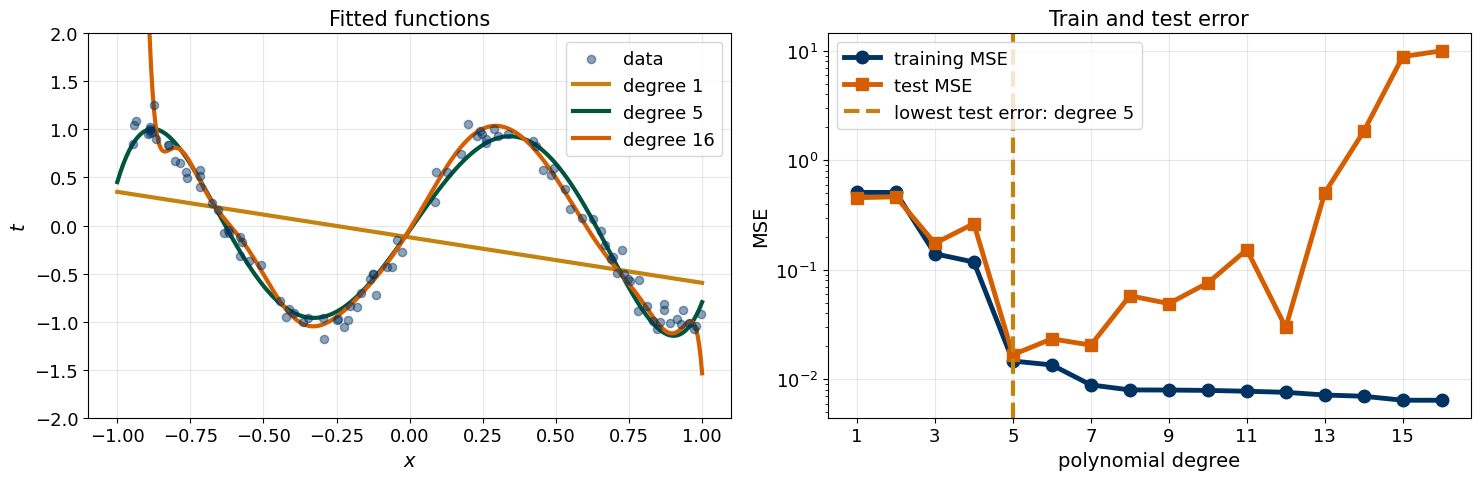

lowest test MSE 0.01681 at degree 5
degree 16: train 0.00645, test 9.97274, max |w_j| 5779.6


In [3]:
ds = list(range(1, 17))
TR, TE, MW = [], [], []
for d in ds:
    P_tr, P_te = build_Phi(x_s[i_tr], d + 1), build_Phi(x_s[i_te], d + 1)
    w = np.linalg.lstsq(P_tr, t_s[i_tr], rcond=None)[0]
    TR.append(np.mean((t_s[i_tr] - P_tr @ w) ** 2))
    TE.append(np.mean((t_s[i_te] - P_te @ w) ** 2))
    MW.append(np.abs(w).max())
k_best = int(np.argmin(TE))

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].scatter(x_s, t_s, s=35, alpha=0.45, color=C_DATA, zorder=3, label="data")
for d, col in zip([1, 5, 16], [C_ALT, C_SPAN, C_RESID]):
    w = np.linalg.lstsq(build_Phi(x_s[i_tr], d + 1), t_s[i_tr], rcond=None)[0]
    axs[0].plot(x_dense, build_Phi(x_dense, d + 1) @ w, lw=3, color=col, label=f"degree {d}")
axs[0].set(xlabel="$x$", ylabel="$t$", ylim=(-2, 2), title="Fitted functions")
axs[0].legend(fontsize=13)

axs[1].semilogy(ds, TR, "o-", lw=3.5, ms=9, color=C_DATA, label="training MSE")
axs[1].semilogy(ds, TE, "s-", lw=3.5, ms=9, color=C_RESID, label="test MSE")
axs[1].axvline(ds[k_best], color=C_ALT, ls="--", lw=3,
               label=f"lowest test error: degree {ds[k_best]}")
axs[1].set(xlabel="polynomial degree", ylabel="MSE", xticks=ds[::2],
           title="Train and test error")
axs[1].legend(fontsize=13)

plt.tight_layout(); plt.show()

print(f"lowest test MSE {TE[k_best]:.5f} at degree {ds[k_best]}")
print(f"degree 16: train {TR[-1]:.5f}, test {TE[-1]:.5f}, max |w_j| {MW[-1]:.1f}")

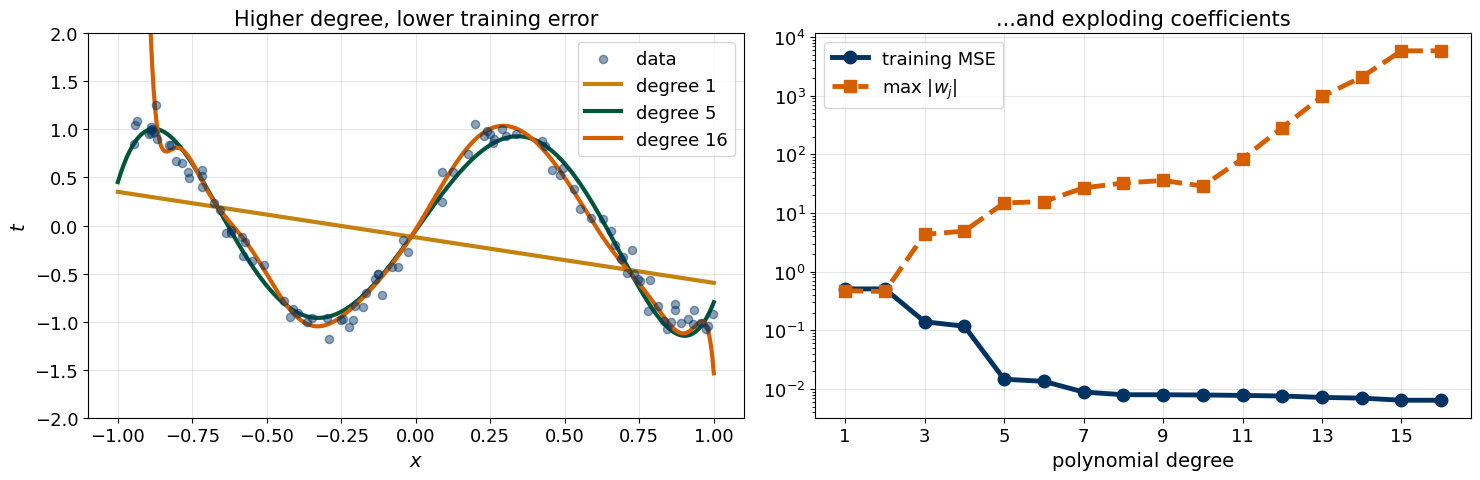

max |w_j| by degree:
  1:0  2:0  3:4  4:5  5:15  6:16  7:27  8:32  9:36  10:29  11:84  12:284  13:967  14:2,056  15:5,768  16:5,780


In [4]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].scatter(x_s, t_s, s=35, alpha=0.45, color=C_DATA, zorder=3, label="data")
for d, col in zip([1, 5, 16], [C_ALT, C_SPAN, C_RESID]):
    w = np.linalg.lstsq(build_Phi(x_s[i_tr], d + 1), t_s[i_tr], rcond=None)[0]
    axs[0].plot(x_dense, build_Phi(x_dense, d + 1) @ w, lw=3, color=col, label=f"degree {d}")
axs[0].set(xlabel="$x$", ylabel="$t$", ylim=(-2, 2),
           title="Higher degree, lower training error")
axs[0].legend(fontsize=13)

axs[1].semilogy(ds, TR, "o-", lw=3.5, ms=9, color=C_DATA, label="training MSE")
axs[1].semilogy(ds, MW, "s--", lw=3.5, ms=9, color=C_RESID, label=r"max $|w_j|$")
axs[1].set(xlabel="polynomial degree", xticks=ds[::2],
           title="...and exploding coefficients")
axs[1].legend(fontsize=13)

plt.tight_layout(); plt.show()

print("max |w_j| by degree:")
print("  " + "  ".join(f"{d}:{m:,.0f}" for d, m in zip(ds, MW)))

### 2. **Regularized Least Squares**

Training error falls, test error turns around, and the coefficients explode. Regularization attacks the coefficients directly:

$$
E(\mathbf{w}) = \underbrace{\tfrac{1}{2}\lVert \mathbf{t} - \Phi\mathbf{w}\rVert^2}_{E_D(\mathbf{w})}
\;+\;\lambda\, \underbrace{E_W(\mathbf{w})}_{\text{penalty}}
$$

| | penalty | closed form? | effect on $\mathbf{w}$ |
|---|---|---|---|
| **Ridge (L2)** | $\tfrac12\lVert\mathbf{w}\rVert_2^2$ | yes: $(\Phi^\top\Phi + \lambda I)^{-1}\Phi^\top\mathbf{t}$ | shrinks all coefficients smoothly |
| **Lasso (L1)** | $\lVert\mathbf{w}\rVert_1$ | no | drives some coefficients **exactly** to zero |

#### 2.1 Coefficient paths

In [5]:
DEG = 10
i_tr2, i_te2 = train_test_split(np.arange(n), test_size=0.85, random_state=189)
# Standardize the polynomial columns: penalties are not scale-invariant, and x^10 is
# numerically tiny next to x^1. Skipping this is the most common bug in ridge/lasso demos.
Ptr_raw = build_Phi(x_s[i_tr2], DEG + 1, bias=False)
mu, sd = Ptr_raw.mean(0), Ptr_raw.std(0)
Ptr = (Ptr_raw - mu) / sd
Pte = (build_Phi(x_s[i_te2], DEG + 1, bias=False) - mu) / sd
ttr, tte = t_s[i_tr2], t_s[i_te2]

lambdas = np.logspace(-6, 2, 40)

def path(Model, penalty):
    coefs, tr, te = [], [], []
    for lam in lambdas:
        m = Model(alpha=lam, fit_intercept=True, max_iter=500_000, tol=1e-8).fit(Ptr, ttr)
        coefs.append(m.coef_.ravel())
        tr.append(mean_squared_error(ttr, m.predict(Ptr)))
        te.append(mean_squared_error(tte, m.predict(Pte)))
    return np.array(coefs), np.array(tr), np.array(te)

ridge_c, ridge_tr, ridge_te = path(Ridge, None)
lasso_c, lasso_tr, lasso_te = path(Lasso, None)

print(f"n_train = {len(i_tr2)} points, degree {DEG} -> {DEG + 1} parameters.")
print(f"unregularized (lambda -> 0) test MSE: {ridge_te[0]:.4f}")
print(f"ridge: best test MSE {ridge_te.min():.4f} at lambda = {lambdas[ridge_te.argmin()]:.4g}"
      f"   ({ridge_te[0]/ridge_te.min():.0f}x better)")
print(f"lasso: best test MSE {lasso_te.min():.4f} at lambda = {lambdas[lasso_te.argmin()]:.4g}")

n_train = 15 points, degree 10 -> 11 parameters.
unregularized (lambda -> 0) test MSE: 37.7041
ridge: best test MSE 0.0836 at lambda = 0.02031   (451x better)
lasso: best test MSE 0.0596 at lambda = 0.0007444


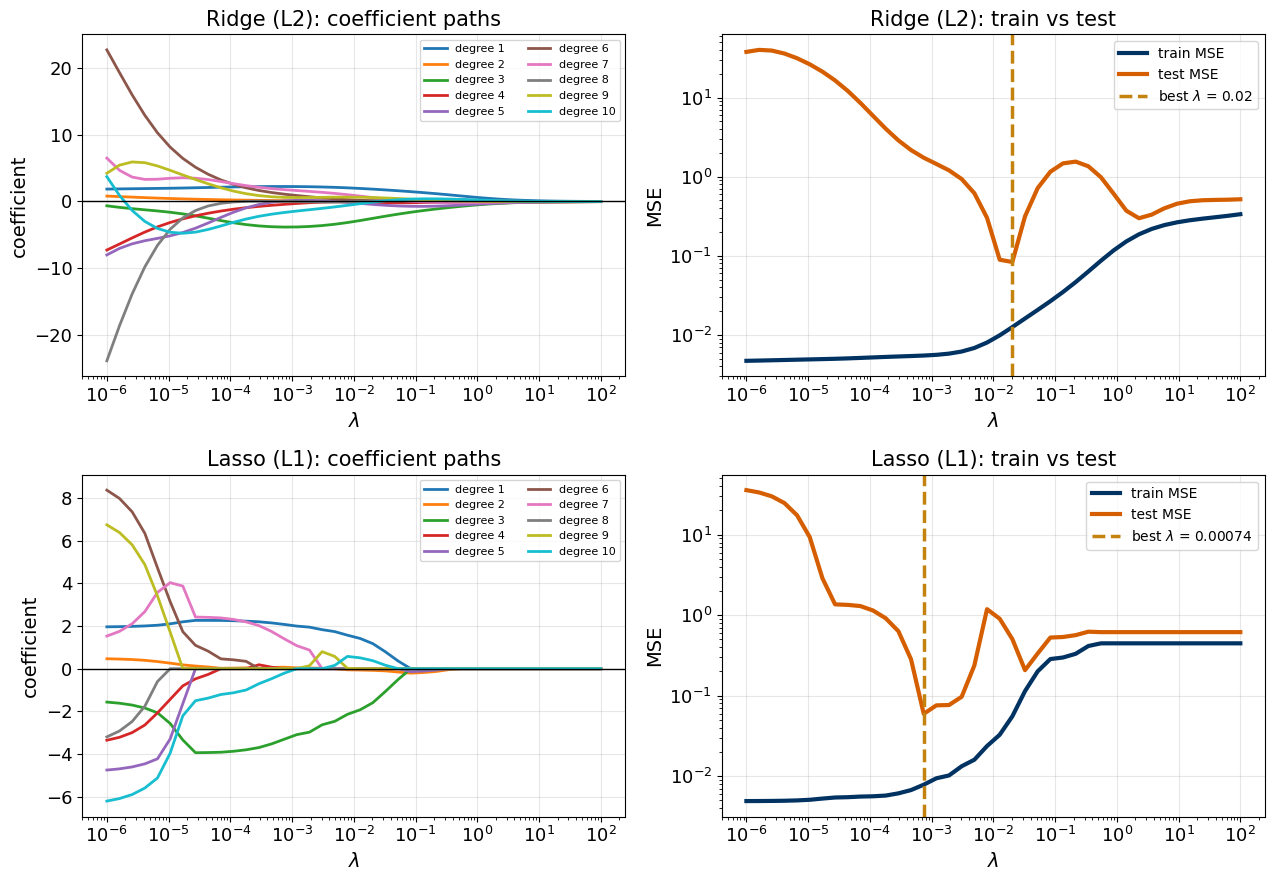

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(13, 9))
for row, (coefs, tr, te, name) in enumerate(
        [(ridge_c, ridge_tr, ridge_te, "Ridge (L2)"),
         (lasso_c, lasso_tr, lasso_te, "Lasso (L1)")]):
    ax = axs[row, 0]
    for j in range(coefs.shape[1]):
        ax.plot(lambdas, coefs[:, j], lw=2, label=f"degree {j+1}")
    ax.axhline(0, color="k", lw=1)
    ax.set(xscale="log", xlabel=r"$\lambda$", ylabel="coefficient",
           title=f"{name}: coefficient paths")
    ax.legend(fontsize=8, ncol=2)

    ax = axs[row, 1]
    ax.plot(lambdas, tr, lw=3, color=C_DATA, label="train MSE")
    ax.plot(lambdas, te, lw=3, color=C_RESID, label="test MSE")
    ax.axvline(lambdas[te.argmin()], color=C_ALT, ls="--", lw=2.5,
               label=rf"best $\lambda$ = {lambdas[te.argmin()]:.2g}")
    ax.set(xscale="log", yscale="log", xlabel=r"$\lambda$", ylabel="MSE",
           title=f"{name}: train vs test")
    ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

#### 2.2 Lasso sets coefficients to zero; ridge does not

Index convention: with the bias column excluded, column $j$ holds $x^{j+1}$, so the first row is **degree 1**, not degree 0.

In [7]:
show = [1e-6, 7e-4, 1e-2, 1e-1, 1e0]
for name, C in (("LASSO", lasso_c), ("RIDGE", ridge_c)):
    rows = {}
    for lam in show:
        j = int(np.argmin(np.abs(lambdas - lam)))
        rows[f"lam={lambdas[j]:.1e}"] = C[j]
    tbl = pd.DataFrame(rows, index=[f"degree {d}" for d in range(1, DEG + 1)])
    print(f"{name} coefficients\n"); print(tbl.round(3).to_string())
    print("exact zeros per lambda:", {c: int((tbl[c] == 0).sum()) for c in tbl.columns}, "\n")

LASSO coefficients

           lam=1.0e-06  lam=7.4e-04  lam=7.9e-03  lam=8.4e-02  lam=8.9e-01
degree 1         1.964        2.078        1.571        0.000         -0.0
degree 2         0.466        0.071       -0.053       -0.209         -0.0
degree 3        -1.566       -3.311       -2.141       -0.000         -0.0
degree 4        -3.356        0.000       -0.000       -0.000         -0.0
degree 5        -4.755        0.000       -0.000       -0.139         -0.0
degree 6         8.378        0.000        0.000       -0.000         -0.0
degree 7         1.530        1.405        0.000       -0.000         -0.0
degree 8        -3.200       -0.000        0.000       -0.000         -0.0
degree 9         6.750        0.000        0.017       -0.000         -0.0
degree 10       -6.211       -0.211        0.578       -0.000         -0.0
exact zeros per lambda: {'lam=1.0e-06': 0, 'lam=7.4e-04': 5, 'lam=7.9e-03': 5, 'lam=8.4e-02': 8, 'lam=8.9e-01': 10} 

RIDGE coefficients

           lam=1.

#### 2.3 The constraint picture

The penalized problem is equivalent to minimizing $E_D(\mathbf{w})$ subject to $E_W(\mathbf{w}) \le c$ for some $c(\lambda)$. The contours of $E_D$ grow until they first touch the constraint region. The L2 region is a **circle**, smooth everywhere; the L1 region is a **diamond** whose corners lie on the axes, and a corner is a point where one coordinate is exactly zero.

In [8]:
W0 = np.array([3.2, 0.9])
th = np.deg2rad(25)
Rot = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
A_MAT = Rot @ np.diag([6.0, 1.0]) @ Rot.T * 2.5

def ridge_solution(lam, A=A_MAT, w0=W0):
    w = np.linalg.solve(A + lam * np.eye(2), A @ w0)
    return w, 0.5 * (w - w0) @ A @ (w - w0), 0.5 * (w @ w)

def lasso_solution(lam, A=A_MAT, w0=W0, iters=4000):
    "Coordinate descent with soft-thresholding: reaches exact zeros, unlike Nelder-Mead."
    w, b = np.zeros(2), A @ w0
    for _ in range(iters):
        for j in range(2):
            rho = b[j] - A[j] @ w + A[j, j] * w[j]
            w[j] = np.sign(rho) * max(abs(rho) - lam, 0.0) / A[j, j]
    return w, 0.5 * (w - w0) @ A @ (w - w0), np.sum(np.abs(w))

for lam in [0.0, 2.0, 6.0, 12.0]:
    wr, wl = ridge_solution(lam)[0], lasso_solution(lam)[0]
    print(f"lambda={lam:5.1f}   ridge w = [{wr[0]:6.3f} {wr[1]:6.3f}]   "
          f"lasso w = [{wl[0]:6.3f} {wl[1]:6.3f}]"
          + ("   <- w2 is exactly 0" if wl[1] == 0.0 else ""))

lambda=  0.0   ridge w = [ 3.200  0.900]   lasso w = [ 3.200  0.900]
lambda=  2.0   ridge w = [ 2.749  0.953]   lasso w = [ 3.203  0.474]
lambda=  6.0   ridge w = [ 2.190  0.847]   lasso w = [ 3.068  0.000]   <- w2 is exactly 0
lambda= 12.0   ridge w = [ 1.691  0.686]   lasso w = [ 2.598  0.000]   <- w2 is exactly 0


In [9]:
def regularization_figure(solver, kind):
    gx = np.linspace(W0[0] - 10, W0[0] + 10, 401)
    gy = np.linspace(W0[1] - 10, W0[1] + 10, 401)
    GX, GY = np.meshgrid(gx, gy)
    U = np.stack([GX - W0[0], GY - W0[1]], axis=-1)
    Z = 0.5 * np.einsum("...i,...i", U, U @ A_MAT)
    zmax = float(np.percentile(Z, 95))

    lams_curve = np.linspace(0.0, 15.0, 400)
    ED, EW = np.array([[solver(l)[1], solver(l)[2]] for l in lams_curve]).T
    Etot = ED + lams_curve * EW
    ymax = float(Etot.max()) * 1.05

    def shape(lam):
        w = solver(lam)[0]
        if kind == "ridge":
            c = np.linalg.norm(w)
            a = np.linspace(0, 2 * np.pi, 400)
            return c * np.cos(a), c * np.sin(a)
        c = np.linalg.norm(w, ord=1)
        return c * np.array([1, 0, -1, 0, 1]), c * np.array([0, 1, 0, -1, 0])

    norm_lbl = "||w||₂ = c(λ)" if kind == "ridge" else "||w||₁ = c(λ)"
    fig = make_subplots(rows=1, cols=2, column_widths=[0.55, 0.45],
                        subplot_titles=(f"{kind.capitalize()}: data contours and constraint region",
                                        "Error decomposition vs λ"))
    fig.add_trace(go.Contour(x=gx, y=gy, z=np.clip(Z, 0, zmax), zmin=0, zmax=zmax,
                             colorscale="Blues", reversescale=True, showscale=False, opacity=0.96,
                             contours=dict(start=0.01 * zmax, end=0.99 * zmax,
                                           size=0.98 * zmax / 20, showlines=False)), row=1, col=1)
    fig.add_trace(go.Scatter(x=[W0[0]], y=[W0[1]], mode="markers",
                             marker=dict(symbol="star", size=16, color="crimson"),
                             name="unregularized optimum"), row=1, col=1)
    for y, nm in [(ED, "E_D"), (lams_curve * EW, "λ·E_W"), (Etot, "E")]:
        fig.add_trace(go.Scatter(x=lams_curve, y=y, mode="lines", line=dict(width=3), name=nm),
                      row=1, col=2)

    cx, cy = shape(0.0)
    dyn = [go.Scatter(x=cx, y=cy, mode="lines",
                      line=dict(width=5, color="darkmagenta"), name=norm_lbl),
           go.Scatter(x=[solver(0.0)[0][0]], y=[solver(0.0)[0][1]], mode="markers",
                      marker=dict(size=14, symbol="x", color="teal"), name="ŵ(λ)"),
           go.Scatter(x=[0, 0], y=[0, ymax], mode="lines",
                      line=dict(width=2, dash="dot", color="teal"), showlegend=False)]
    for tr, col in zip(dyn, [1, 1, 2]):
        fig.add_trace(tr, row=1, col=col)
    dyn_ix = list(range(len(fig.data) - 3, len(fig.data)))

    lams = np.linspace(0.0, 15.0, 16)
    fig.frames = [go.Frame(name=f"{l:.2f}", traces=dyn_ix, data=[
        go.Scatter(x=shape(l)[0], y=shape(l)[1]),
        go.Scatter(x=[solver(l)[0][0]], y=[solver(l)[0][1]]),
        go.Scatter(x=[l, l], y=[0, ymax])]) for l in lams]

    fig.update_layout(
        template="plotly_white", height=560,
        sliders=[dict(active=0, pad=dict(l=100, t=55), steps=[
            {"label": f"λ = {l:.1f}", "method": "animate",
             "args": [[f"{l:.2f}"], {"mode": "immediate",
                                     "frame": {"duration": 0, "redraw": True},
                                     "transition": {"duration": 0}}]} for l in lams])],
        updatemenus=[dict(type="buttons", x=0.02, y=0, xanchor="left", yanchor="bottom",
                          direction="left", buttons=[
            dict(label="▶", method="animate", args=[None, {"fromcurrent": True,
                 "frame": {"duration": 600, "redraw": True}, "transition": {"duration": 50}}]),
            dict(label="⏸", method="animate", args=[[None], {"mode": "immediate",
                 "frame": {"duration": 0, "redraw": False}}])])])
    fig.update_xaxes(title_text="w₁", range=[W0[0] - 10, W0[0] + 10], row=1, col=1)
    fig.update_yaxes(title_text="w₂", range=[W0[1] - 10, W0[1] + 10],
                     scaleanchor="x", scaleratio=1, row=1, col=1)
    fig.update_xaxes(title_text="λ", row=1, col=2)
    return fig

regularization_figure(ridge_solution, "ridge").show()

In [10]:
regularization_figure(lasso_solution, "lasso").show()

### 3. **Least Squares $\equiv$ Maximum Likelihood**

Assume the target is the model output plus zero-mean Gaussian noise:

$$
t = y(\mathbf{x}, \mathbf{w}) + \varepsilon,\qquad \varepsilon \sim \mathcal{N}(0, \sigma^2)
\qquad\Longrightarrow\qquad
p(t \mid \mathbf{x}, \mathbf{w}, \sigma^2) = \mathcal{N}\big(t \,\big|\, y(\mathbf{x},\mathbf{w}),\, \sigma^2\big)
$$

With i.i.d. data, the log-likelihood is

$$
\ln p(\mathbf{t}\mid\mathbf{w},\sigma^2)
= -\frac{1}{2\sigma^2}\underbrace{\sum_{n}\big(t_n - \mathbf{w}^\top\boldsymbol{\phi}(\mathbf{x}_n)\big)^2}_{2\,E(\mathbf{w})}
\;-\;\frac{N}{2}\ln\sigma^2 \;-\;\frac{N}{2}\ln 2\pi
$$

Only the first term depends on $\mathbf{w}$, and it is $-E(\mathbf{w})/\sigma^2$. Maximizing the likelihood in $\mathbf{w}$ is minimizing the sum-of-squares error, whatever $\sigma^2$ is.

In [11]:
rng2 = np.random.default_rng(0)
N, sigma_true = 80, 1.0
xm = np.linspace(0, 5, N)
Phi_m = np.column_stack([np.ones_like(xm), xm])      # [1, x] -> w = [intercept, slope]
w_true = np.array([1.0, 2.0])
tm = Phi_m @ w_true + rng2.normal(0, sigma_true, N)

def sse(w):        return float(np.sum((tm - Phi_m @ w) ** 2))
def loglik(w, s2): return -0.5 * sse(w) / s2 - 0.5 * N * np.log(s2) - 0.5 * N * np.log(2 * np.pi)

w_ls = np.linalg.lstsq(Phi_m, tm, rcond=None)[0]
print("least-squares estimate w_hat :", np.array2string(w_ls, precision=4))
print("true parameters      w*      :", np.array2string(w_true, precision=4))
print("\nSSE at w_hat     :", round(sse(w_ls), 4))
print("log-lik at w_hat :", round(loglik(w_ls, sigma_true ** 2), 4))

least-squares estimate w_hat : [0.8523 2.1072]
true parameters      w*      : [1. 2.]

SSE at w_hat     : 72.3206
log-lik at w_hat : -109.6754


argmin SSE on the grid : (np.float64(0.85), np.float64(2.108))
argmax logL on the grid: (np.float64(0.85), np.float64(2.108))
same grid cell? True


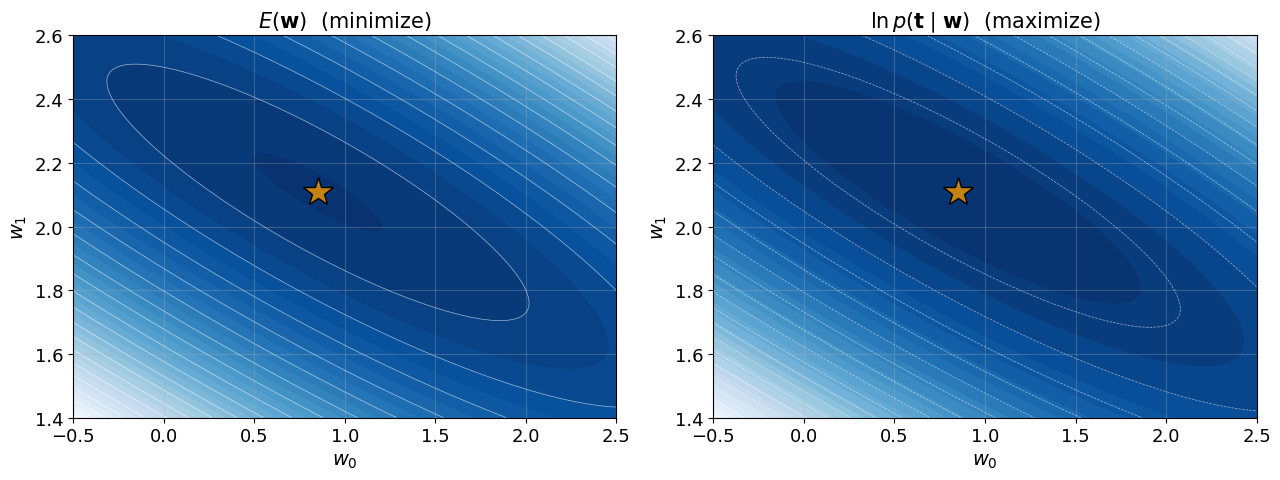

In [12]:
# Grid search the log-likelihood and confirm its argmax is the least-squares solution.
g0 = np.linspace(w_true[0] - 1.5, w_true[0] + 1.5, 301)
g1 = np.linspace(w_true[1] - 0.6, w_true[1] + 0.6, 301)
G0, G1 = np.meshgrid(g0, g1)
R = tm[None, None, :] - (G0[..., None] * Phi_m[:, 0] + G1[..., None] * Phi_m[:, 1])
SSE = np.sum(R ** 2, axis=-1)
LL = -0.5 * SSE / sigma_true**2 - 0.5 * N * np.log(sigma_true**2) - 0.5 * N * np.log(2 * np.pi)

i_sse = np.unravel_index(SSE.argmin(), SSE.shape)
i_ll  = np.unravel_index(LL.argmax(),  LL.shape)
print("argmin SSE on the grid :", (round(G0[i_sse], 4), round(G1[i_sse], 4)))
print("argmax logL on the grid:", (round(G0[i_ll], 4),  round(G1[i_ll], 4)))
print("same grid cell?", i_sse == i_ll)

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for ax, Z, name, cm in [(axs[0], SSE, "$E(\\mathbf{w})$  (minimize)", "Blues_r"),
                        (axs[1], LL, "$\\ln p(\\mathbf{t}\\mid\\mathbf{w})$  (maximize)", "Blues")]:
    ax.contourf(G0, G1, Z, levels=40, cmap=cm)
    ax.contour(G0, G1, Z, levels=18, colors="white", linewidths=0.5, alpha=0.6)
    ax.plot(*w_ls, marker="*", ms=22, color=C_ALT, mec="k", zorder=5)
    ax.set(xlabel="$w_0$", ylabel="$w_1$", title=name)
plt.tight_layout(); plt.show()

#### 3.1 The noise variance comes out too

Maximizing over $\sigma^2$ as well gives the residual variance around the fitted function:

$$
\sigma^2_{\text{ML}} = \frac{1}{N}\sum_{n=1}^{N}\big(t_n - \hat{\mathbf{w}}^\top\boldsymbol{\phi}(\mathbf{x}_n)\big)^2
$$

sigma^2_ML   = 0.9040
true sigma^2 = 1.0000
argmax over the sigma^2 grid = 0.9065


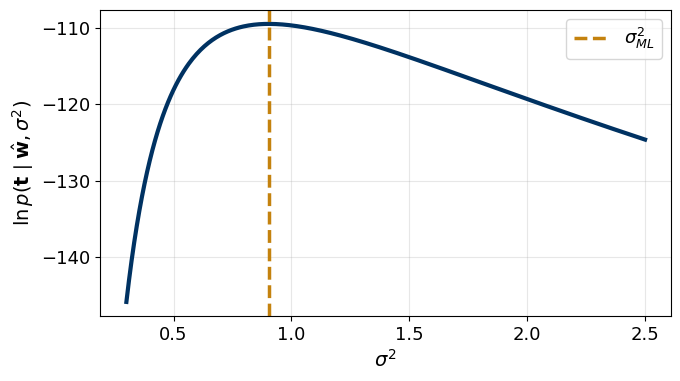

In [13]:
sigma2_ml = np.mean((tm - Phi_m @ w_ls) ** 2)
print(f"sigma^2_ML   = {sigma2_ml:.4f}")
print(f"true sigma^2 = {sigma_true**2:.4f}")

grid_s2 = np.linspace(0.3, 2.5, 400)
ll_s2 = np.array([loglik(w_ls, s2) for s2 in grid_s2])
print(f"argmax over the sigma^2 grid = {grid_s2[ll_s2.argmax()]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid_s2, ll_s2, lw=3, color=C_DATA)
ax.axvline(sigma2_ml, color=C_ALT, lw=2.5, ls="--", label=r"$\sigma^2_{ML}$")
ax.set(xlabel=r"$\sigma^2$", ylabel=r"$\ln p(\mathbf{t}\mid\hat{\mathbf{w}},\sigma^2)$")
ax.legend(); plt.tight_layout(); plt.show()

### 4. **Choosing a Noise Model**

The chain runs *noise distribution $\to$ likelihood $\to$ error function*. Squared error is what a Gaussian gives you. A Laplace noise model, which has heavier tails, gives absolute error:

$$
\varepsilon \sim \mathcal{N}(0,\sigma^2) \;\Rightarrow\; -\ln p \propto \varepsilon^2 \;\Rightarrow\; \textbf{MSE}
\qquad\qquad
\varepsilon \sim \text{Laplace}(0,b) \;\Rightarrow\; -\ln p \propto |\varepsilon| \;\Rightarrow\; \textbf{MAE}
$$

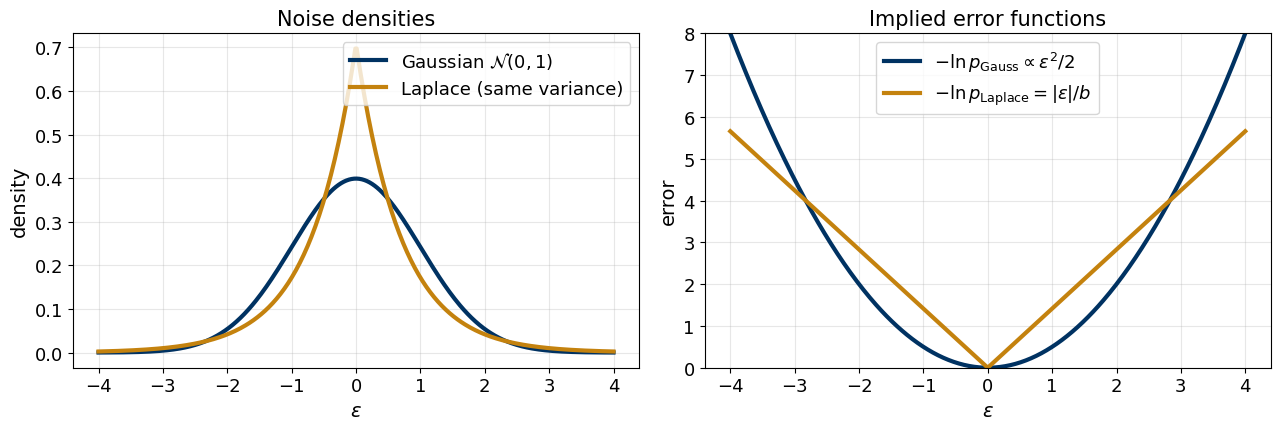

In [14]:
eps = np.linspace(-4, 4, 400)
b = 1 / np.sqrt(2)                      # Laplace(b) has variance 2b^2, matching N(0,1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(eps, st.norm(0, 1).pdf(eps), lw=3, color=C_DATA, label="Gaussian $\\mathcal{N}(0,1)$")
ax[0].plot(eps, st.laplace(0, b).pdf(eps), lw=3, color=C_ALT, label="Laplace (same variance)")
ax[0].set(title="Noise densities", xlabel=r"$\varepsilon$", ylabel="density"); ax[0].legend()

ax[1].plot(eps, 0.5 * eps ** 2, lw=3, color=C_DATA, label=r"$-\ln p_{\rm Gauss} \propto \varepsilon^2/2$")
ax[1].plot(eps, np.abs(eps) / b, lw=3, color=C_ALT, label=r"$-\ln p_{\rm Laplace} = |\varepsilon|/b$")
ax[1].set(title="Implied error functions", xlabel=r"$\varepsilon$", ylabel="error", ylim=(0, 8))
ax[1].legend()
plt.tight_layout(); plt.show()

#### 4.1 Behaviour under a single outlier

The quadratic arm of squared error means one bad measurement can move the whole fit.

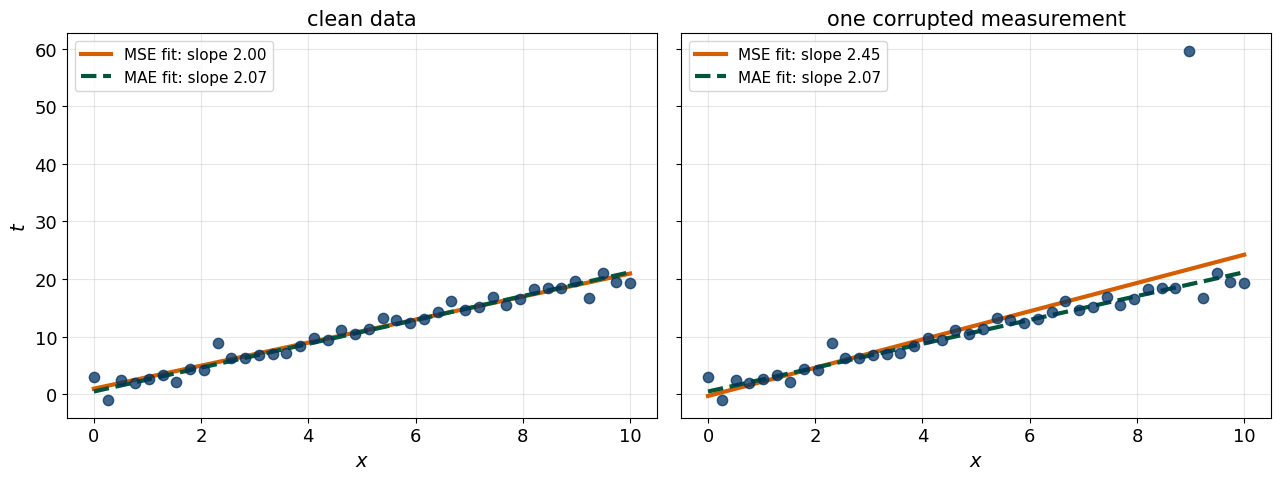

slope, clean data   -> MSE 1.999 | MAE 2.071
slope, with outlier -> MSE 2.452 | MAE 2.071


In [15]:
x_o = np.linspace(0, 10, 40)
t_o = 1 + 2 * x_o + np.random.default_rng(3).normal(0, 1.0, 40)
t_o_bad = t_o.copy(); t_o_bad[35] += 40.0          # one corrupted measurement

Phi_o = np.column_stack([np.ones_like(x_o), x_o])
def fit_mse(t): return np.linalg.lstsq(Phi_o, t, rcond=None)[0]
def fit_mae(t): return minimize(lambda w: np.abs(t - Phi_o @ w).sum(),
                                fit_mse(t), method="Nelder-Mead",
                                options=dict(xatol=1e-9, fatol=1e-9, maxiter=8000)).x

fig, axs = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, tt, name in [(axs[0], t_o, "clean data"),
                     (axs[1], t_o_bad, "one corrupted measurement")]:
    ax.scatter(x_o, tt, s=55, color=C_DATA, alpha=0.75, zorder=3)
    wm, wa = fit_mse(tt), fit_mae(tt)
    ax.plot(x_o, Phi_o @ wm, lw=3, color=C_RESID, label=f"MSE fit: slope {wm[1]:.2f}")
    ax.plot(x_o, Phi_o @ wa, lw=3, ls="--", color=C_SPAN, label=f"MAE fit: slope {wa[1]:.2f}")
    ax.set(xlabel="$x$", title=name); ax.legend(loc="upper left", fontsize=11)
axs[0].set_ylabel("$t$")
plt.tight_layout(); plt.show()

print("slope, clean data   -> MSE %.3f | MAE %.3f" % (fit_mse(t_o)[1], fit_mae(t_o)[1]))
print("slope, with outlier -> MSE %.3f | MAE %.3f" % (fit_mse(t_o_bad)[1], fit_mae(t_o_bad)[1]))

### 5. **Regularization as a Prior Belief**

Lecture 06 introduced ridge as "add a penalty so the weights stay small". The probabilistic view says where that penalty comes from: a prior belief that the weights are small. Put $\mathbf{w} \sim \mathcal{N}(\mathbf{0}, \tau^2 I)$ and maximize the posterior instead of the likelihood:

$$
\hat{\mathbf{w}}_{\text{MAP}} = \arg\max_{\mathbf{w}} \big[\ln p(\mathbf{t}\mid\mathbf{w},\sigma^2) + \ln p(\mathbf{w})\big]
= \arg\min_{\mathbf{w}} \left[\tfrac{1}{2\sigma^2}\lVert\mathbf{t}-\Phi\mathbf{w}\rVert^2 + \tfrac{1}{2\tau^2}\lVert\mathbf{w}\rVert^2\right]
$$

Multiply through by $\sigma^2$ and this is ridge regression with

$$
\lambda = \frac{\sigma^2}{\tau^2}
$$

$\lambda$ is a ratio of variances: how noisy the data is believed to be, relative to how large the weights are believed to be.

In [16]:
sigma2, tau2 = 0.25, 0.10
lam_map = sigma2 / tau2

raw = build_Phi(x_s, 7, bias=False)
Phi_map = (raw - raw.mean(0)) / raw.std(0)
t_c = t_s - t_s.mean()                                  # centred, so no intercept to handle

w_map = np.linalg.solve(Phi_map.T @ Phi_map / sigma2 + np.eye(Phi_map.shape[1]) / tau2,
                        Phi_map.T @ t_c / sigma2)
w_ridge = np.linalg.solve(Phi_map.T @ Phi_map + lam_map * np.eye(Phi_map.shape[1]),
                          Phi_map.T @ t_c)

print(f"lambda = sigma^2 / tau^2 = {sigma2} / {tau2} = {lam_map:.1f}\n")
print("MAP   (posterior mode):", np.array2string(w_map,   precision=6))
print("Ridge (lambda = 2.5)  :", np.array2string(w_ridge, precision=6))
print("\nmax |difference| =", f"{np.abs(w_map - w_ridge).max():.2e}")

print("\nA tighter prior shrinks harder:")
for tau2_i in [10.0, 1.0, 0.1, 0.01]:
    li = sigma2 / tau2_i
    wi = np.linalg.solve(Phi_map.T @ Phi_map + li * np.eye(Phi_map.shape[1]), Phi_map.T @ t_c)
    print(f"  tau^2 = {tau2_i:>6} -> lambda = {li:>7.2f} -> ||w|| = {np.linalg.norm(wi):.3f}")

lambda = sigma^2 / tau^2 = 0.25 / 0.1 = 2.5

MAP   (posterior mode): [ 0.794008 -0.004324 -1.035283 -0.037961 -0.203844  0.123328]
Ridge (lambda = 2.5)  : [ 0.794008 -0.004324 -1.035283 -0.037961 -0.203844  0.123328]

max |difference| = 0.00e+00

A tighter prior shrinks harder:
  tau^2 =   10.0 -> lambda =    0.03 -> ||w|| = 7.068
  tau^2 =    1.0 -> lambda =    0.25 -> ||w|| = 4.498
  tau^2 =    0.1 -> lambda =    2.50 -> ||w|| = 1.327
  tau^2 =   0.01 -> lambda =   25.00 -> ||w|| = 0.461


The same substitution with a **Laplace** prior on $\mathbf{w}$ gives the lasso. The two regularizers we used mechanically last lecture are two choices of prior.

### 6. **The Bias-Variance Decomposition**

Take the expected squared error at an input $x$, averaged over training sets $\mathcal{D}$:

$$
\mathbb{E}_{\mathcal{D}}\big[(t - y(x;\mathcal{D}))^2\big]
= \underbrace{\sigma^2}_{\text{noise}}
+ \underbrace{\big(\mathbb{E}_{\mathcal{D}}[y(x;\mathcal{D})] - f(x)\big)^2}_{\text{bias}^2}
+ \underbrace{\mathbb{E}_{\mathcal{D}}\big[(y(x;\mathcal{D}) - \mathbb{E}_{\mathcal{D}}[y(x;\mathcal{D})])^2\big]}_{\text{variance}}
$$

- **Noise** is irreducible. No model removes it.
- **Bias** is how far the *average* fitted function sits from the truth: underfitting.
- **Variance** is how much the fitted function moves when the training set changes: overfitting.

Every term is an expectation over training sets, so we can estimate all three by simulation: draw many training sets, fit each, and look at the spread of the fitted functions.

In [17]:
SIGMA_BV, NSETS = 0.30, 400
f_true = lambda x: np.sin(5 * x)
xg_bv = np.linspace(-0.9, 0.9, 120)

def Phi_leg(x, deg):
    "Legendre basis: well conditioned, so what we measure is variance and not rounding error."
    return L.legvander(np.asarray(x).ravel(), deg)

def decompose(n_train, degrees, seed=189):
    rng = np.random.default_rng(seed)
    out = []
    for d in degrees:
        preds = np.empty((NSETS, len(xg_bv)))
        for s in range(NSETS):
            xt = rng.uniform(-0.9, 0.9, n_train)
            tt = f_true(xt) + SIGMA_BV * rng.standard_normal(n_train)
            w = np.linalg.lstsq(Phi_leg(xt, d), tt, rcond=None)[0]
            preds[s] = Phi_leg(xg_bv, d) @ w
        bias2 = float(np.mean((preds.mean(0) - f_true(xg_bv)) ** 2))
        var = float(np.mean(preds.var(0)))
        out.append((d, bias2, var, SIGMA_BV ** 2, bias2 + var + SIGMA_BV ** 2, preds))
    return out

degrees = list(range(0, 11))
res100 = decompose(100, degrees)

print(f"N_train = 100,  {NSETS} training sets per degree\n")
print(f"{'deg':>4} {'bias^2':>9} {'variance':>9} {'noise':>8} {'total':>9}")
for d, b2, v, nz, tot, _ in res100:
    print(f"{d:>4} {b2:>9.4f} {v:>9.4f} {nz:>8.4f} {tot:>9.4f}")
best = min(res100, key=lambda r: r[4])
print(f"\nlowest expected error at degree {best[0]}  (total {best[4]:.4f})")

N_train = 100,  400 training sets per degree

 deg    bias^2  variance    noise     total
   0    0.4811    0.0053   0.0900    0.5764
   1    0.4813    0.0112   0.0900    0.5824
   2    0.4813    0.0191   0.0900    0.5904
   3    0.0726    0.0080   0.0900    0.1706
   4    0.0728    0.0120   0.0900    0.1748
   5    0.0017    0.0067   0.0900    0.0984
   6    0.0018    0.0084   0.0900    0.1001
   7    0.0000    0.0097   0.0900    0.0998
   8    0.0000    0.0128   0.0900    0.1028
   9    0.0001    0.0204   0.0900    0.1105
  10    0.0000    0.0329   0.0900    0.1229

lowest expected error at degree 5  (total 0.0984)


#### 6.1 Seeing bias and variance directly

Plot the fitted function from 40 of the training sets, plus their average, against the truth. Bias is the gap between the average (dashed) and the truth (solid). Variance is the width of the grey band.

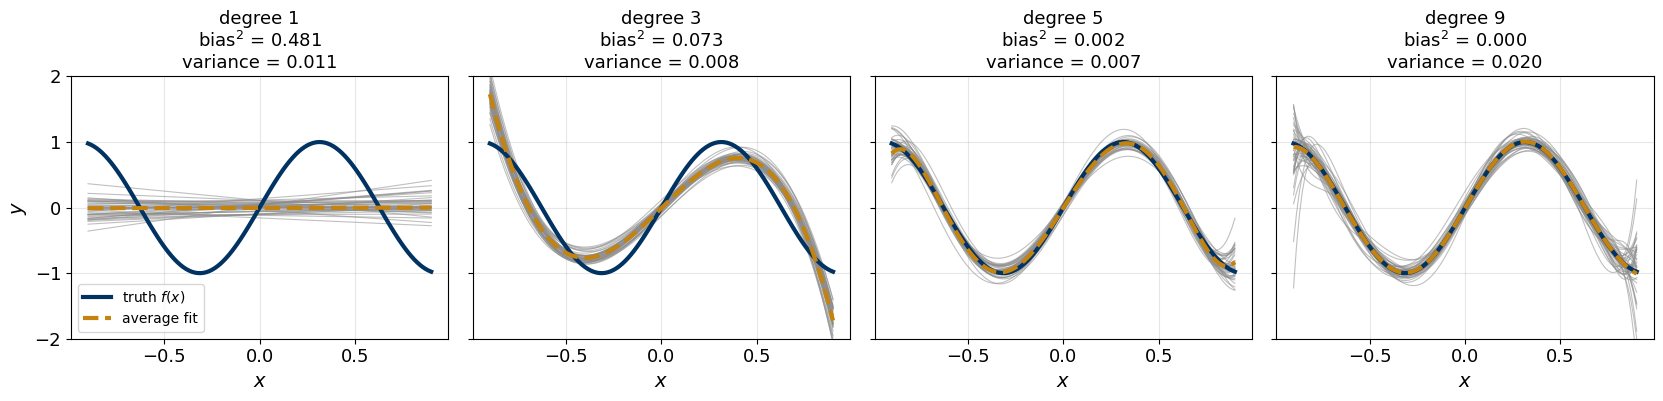

In [18]:
show_degrees = [1, 3, 5, 9]
fig, axs = plt.subplots(1, 4, figsize=(17, 4.2), sharey=True)
for ax, d in zip(axs, show_degrees):
    rec = [r for r in res100 if r[0] == d][0]
    preds = rec[5]
    for p in preds[:40]:
        ax.plot(xg_bv, p, color="0.55", lw=0.8, alpha=0.55)
    ax.plot(xg_bv, f_true(xg_bv), lw=3, color=C_DATA, label="truth $f(x)$")
    ax.plot(xg_bv, preds.mean(0), lw=3, ls="--", color=C_ALT, label="average fit")
    ax.set_title(f"degree {d}\nbias$^2$ = {rec[1]:.3f}\nvariance = {rec[2]:.3f}", fontsize=13)
    ax.set(xlabel="$x$", ylim=(-2.0, 2.0))
axs[0].set_ylabel("$y$"); axs[0].legend(fontsize=10, loc="lower left")
plt.tight_layout(); plt.show()

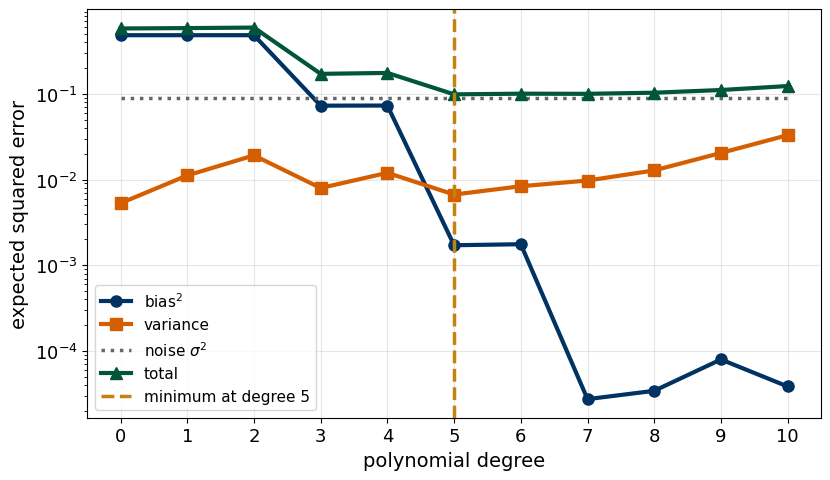

In [19]:
b2 = np.array([r[1] for r in res100])
vr = np.array([r[2] for r in res100])
nz = np.array([r[3] for r in res100])
tot = b2 + vr + nz

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(degrees, b2, "o-", lw=3, ms=8, color=C_DATA, label="bias$^2$")
ax.plot(degrees, vr, "s-", lw=3, ms=8, color=C_RESID, label="variance")
ax.plot(degrees, nz, ":", lw=2.5, color="0.4", label="noise $\\sigma^2$")
ax.plot(degrees, tot, "^-", lw=3, ms=8, color=C_SPAN, label="total")
ax.axvline(degrees[int(tot.argmin())], color=C_ALT, ls="--", lw=2.5,
           label=f"minimum at degree {degrees[int(tot.argmin())]}")
ax.set(xlabel="polynomial degree", ylabel="expected squared error", yscale="log",
       xticks=degrees)
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

#### 6.2 More data supports more complexity

Nothing about the tradeoff is a property of the model alone. Shrink the training set and the variance term grows at every degree, so the minimum moves left: with less data the best model is *simpler* than the truth.

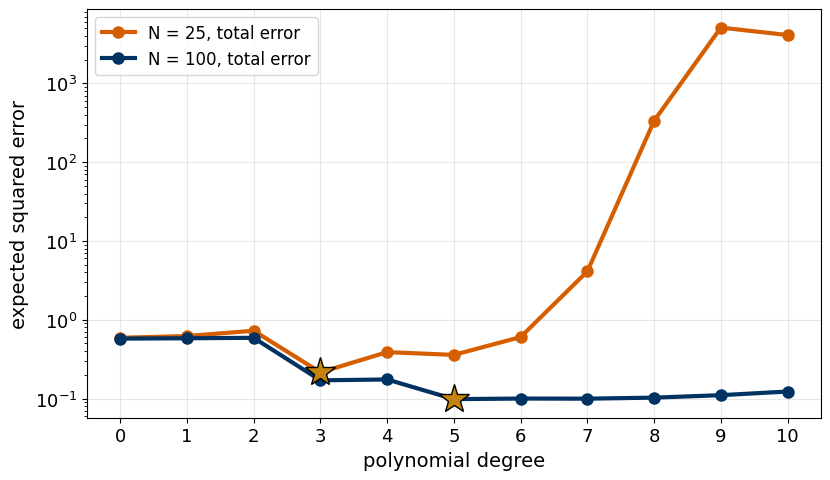

N = 25  -> minimum at degree 3 (total 0.2151)
N = 100 -> minimum at degree 5 (total 0.0984)


In [20]:
res25 = decompose(25, degrees)
tot25 = np.array([r[4] for r in res25])

fig, ax = plt.subplots(figsize=(8.5, 5))
for res, tot_i, col, name in [(res25, tot25, C_RESID, "N = 25"),
                              (res100, tot, C_DATA, "N = 100")]:
    ax.plot(degrees, tot_i, "o-", lw=3, ms=8, color=col, label=f"{name}, total error")
    k = int(np.argmin(tot_i))
    ax.plot(degrees[k], tot_i[k], "*", ms=22, color=C_ALT, mec="k", zorder=5)
ax.set(xlabel="polynomial degree", ylabel="expected squared error", yscale="log",
       xticks=degrees)
ax.legend(fontsize=12); plt.tight_layout(); plt.show()

print(f"N = 25  -> minimum at degree {degrees[int(tot25.argmin())]} (total {tot25.min():.4f})")
print(f"N = 100 -> minimum at degree {degrees[int(tot.argmin())]} (total {tot.min():.4f})")

#### 6.3 Regularization moves along the same curve

Model complexity is not only the number of basis functions. Hold the degree fixed at 9 and turn $\lambda$ instead: large $\lambda$ buys bias and sells variance, exactly as reducing the degree does.

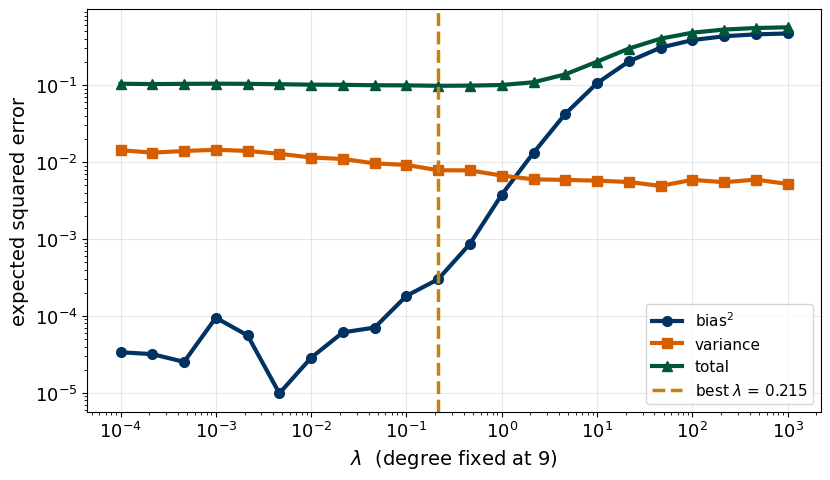

lambda -> 0     : bias^2 0.0000, variance 0.0143
best lambda     : bias^2 0.0003, variance 0.0078  (lambda = 0.215)
lambda -> large : bias^2 0.4699, variance 0.0052


In [21]:
def decompose_ridge(n_train, deg, lambdas, seed=189):
    rng = np.random.default_rng(seed)
    out = []
    for lam in lambdas:
        preds = np.empty((NSETS, len(xg_bv)))
        for s in range(NSETS):
            xt = rng.uniform(-0.9, 0.9, n_train)
            tt = f_true(xt) + SIGMA_BV * rng.standard_normal(n_train)
            A = Phi_leg(xt, deg)
            P = np.eye(deg + 1); P[0, 0] = 0.0           # intercept left unpenalized
            w = np.linalg.solve(A.T @ A + lam * P, A.T @ tt)
            preds[s] = Phi_leg(xg_bv, deg) @ w
        bias2 = float(np.mean((preds.mean(0) - f_true(xg_bv)) ** 2))
        var = float(np.mean(preds.var(0)))
        out.append((lam, bias2, var, bias2 + var + SIGMA_BV ** 2))
    return out

lams = np.logspace(-4, 3, 22)
rr = decompose_ridge(100, 9, lams)
b2r = np.array([r[1] for r in rr]); vrr = np.array([r[2] for r in rr])
totr = np.array([r[3] for r in rr])

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(lams, b2r, "o-", lw=3, ms=7, color=C_DATA, label="bias$^2$")
ax.plot(lams, vrr, "s-", lw=3, ms=7, color=C_RESID, label="variance")
ax.plot(lams, totr, "^-", lw=3, ms=7, color=C_SPAN, label="total")
ax.axvline(lams[int(totr.argmin())], color=C_ALT, ls="--", lw=2.5,
           label=rf"best $\lambda$ = {lams[int(totr.argmin())]:.3g}")
ax.set(xscale="log", yscale="log", xlabel=r"$\lambda$  (degree fixed at 9)",
       ylabel="expected squared error")
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

print(f"lambda -> 0     : bias^2 {b2r[0]:.4f}, variance {vrr[0]:.4f}")
print(f"best lambda     : bias^2 {b2r[totr.argmin()]:.4f}, variance {vrr[totr.argmin()]:.4f}"
      f"  (lambda = {lams[int(totr.argmin())]:.3g})")
print(f"lambda -> large : bias^2 {b2r[-1]:.4f}, variance {vrr[-1]:.4f}")